In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
##========TASK-1 = DATA EXPLORATION WITH PANDAS==============

import pandas as pd

## LOAD SCV FILE DATASET
df = pd.read_csv("students.csv")

print("first 5 rows")
print(df.head())

print("shape of dataset")
print(df.shape)

print("data types")
print(df.dtypes)

print("summary statistics")
print(df.describe())

print("pass vs fail count")
print(df["passed"].value_counts())

subjects = ["math", "science", "english", "history", "pe"]

## AVERAGE SCORE OF STUDENT(PASS STUDENTS )
passed_avg = df[df["passed"] == 1][subjects].mean()
print("average scores for passed students")
print(passed_avg)

## AVERAGE SCORE OF STUDENT (FAIL STUDENTS)
failed_avg = df[df["passed"] == 0][subjects].mean()
print("average scores for failed students")
print(failed_avg)

## STUDENT WITH HIGHEST MARKS (TOPERS)
df["overall_avg"] = df[subjects].mean(axis=1)
top_student = df.loc[df["overall_avg"].idxmax()]

print("top student")
print(top_student["name"], "Average:", round(top_student["overall_avg"], 2))

first 5 rows
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
shape of dataset
(15, 9)
data types
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
summary statistics
            math    science    english

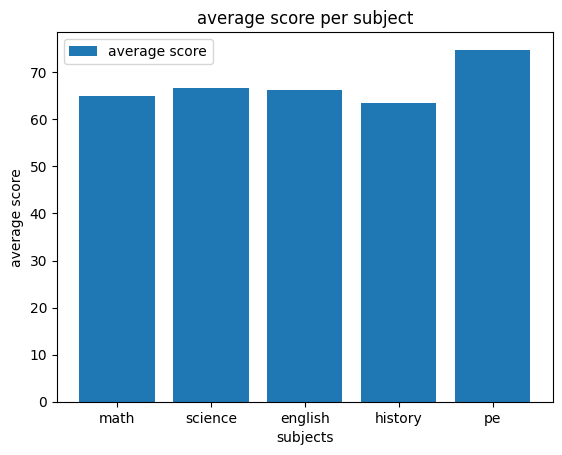

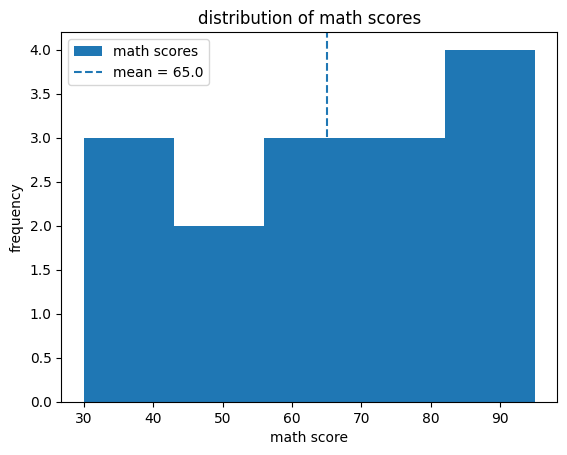

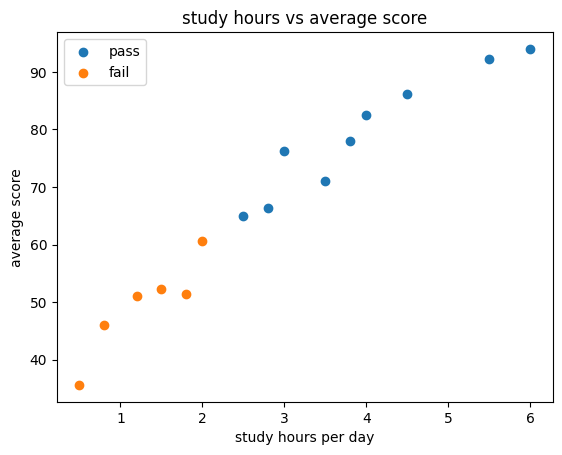

C:\Users\Pranav Bhoir\AppData\Local\Temp\ipykernel_5612\2721642041.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['pass', 'fail'])
C:\Users\Pranav Bhoir\AppData\Local\Temp\ipykernel_5612\2721642041.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


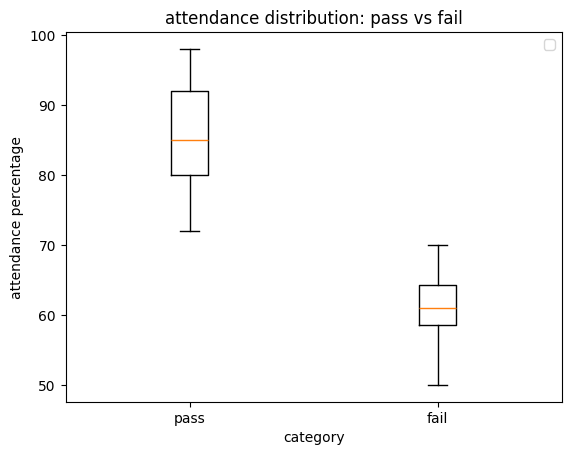

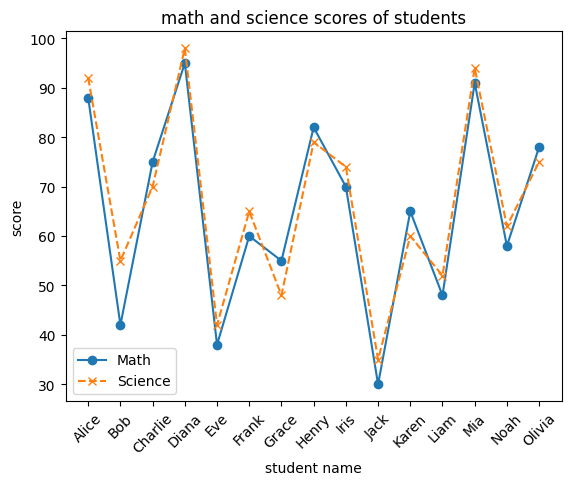

In [2]:
##==========TASK-2 = DATA SISUALIZATION WITH MATPLOTIB==========


## DATA FRAME
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)



import matplotlib.pyplot as plt
data = pd.read_csv("students.csv")

data['avg_score'] = data[subjects].mean(axis=1)

## BAR CHART

avg_scores = data[subjects].mean()

plt.figure()

x_axis = list(avg_scores.index)
y_axis = []

for val in avg_scores:
    y_axis.append(val)

plt.bar(x_axis, y_axis, label="average score")
plt.title("average score per subject")

plt.xlabel("subjects")
plt.ylabel("average score")

plt.legend()

plt.savefig("plot1_bar.png")
plt.show()

## HISTOGRAM

plt.figure()

math_scores = df['math']

plt.hist(math_scores, bins=5, label="math scores")

avg_val = math_scores.mean()

plt.axvline(avg_val, linestyle='dashed', label="mean = " + str(round(avg_val, 2)))

plt.title("distribution of math scores")
plt.xlabel("math score")
plt.ylabel("frequency")

plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

## SCATTER PLOT

plt.figure()

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label='pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label='fail')

plt.title("study hours vs average score")
plt.xlabel("study hours per day")
plt.ylabel("average score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

## BOX PLOT

plt.figure()

passed_vals = df[df['passed'] == 1]['attendance_pct']
failed_vals = df[df['passed'] == 0]['attendance_pct']

p_list = list(passed_vals)
f_list = list(failed_vals)

data_to_plot = [p_list, f_list]

plt.boxplot(data_to_plot, labels=['pass', 'fail'])

plt.title("attendance distribution: pass vs fail")
plt.xlabel("category")
plt.ylabel("attendance percentage")

plt.legend()

plt.savefig("plot4_box.png")

## LINE PLOT

plt.figure()

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='x', linestyle='--', label='Science')


plt.title("math and science scores of students")
plt.xlabel("student name")
plt.ylabel("score")

plt.xticks(rotation=45)

plt.legend()

plt.savefig("plot5_line.png")
plt.show()


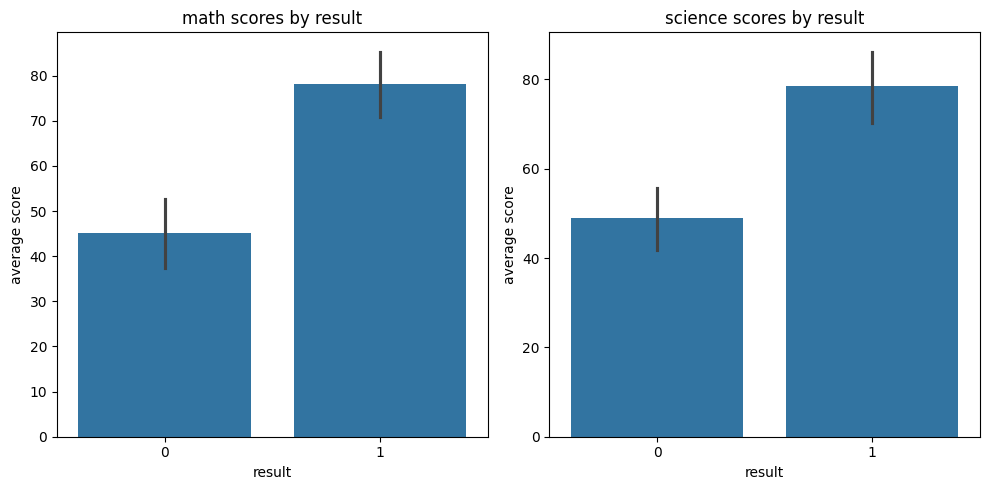

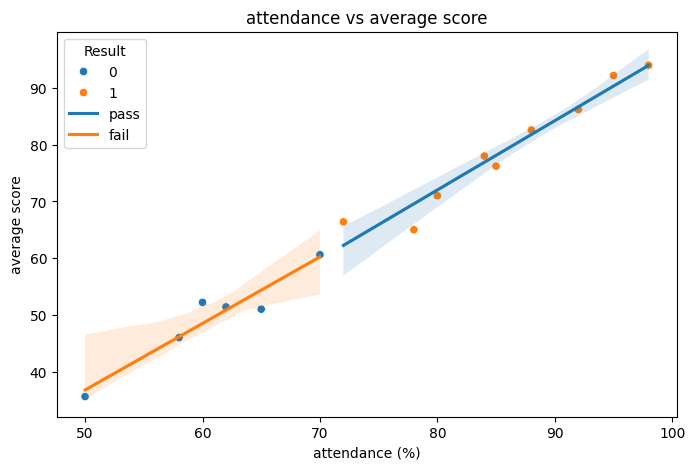

In [3]:
##=======PART-3 = DATA VISUALIZATION WITH SEABORN==========

## SEABORN BAR PLOTE 
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

## MATH SCORE BY PASS OR FAIL
sns.barplot(data=df, x='passed', y='math', ax=axes[0])
axes[0].set_title("math scores by result")
axes[0].set_xlabel("result")
axes[0].set_ylabel("average score")

## SCIENCE SCORE BY PASS OR FAIL
sns.barplot(data=df, x='passed', y='science', ax=axes[1])
axes[1].set_title("science scores by result")
axes[1].set_xlabel("result")
axes[1].set_ylabel("average score")

plt.tight_layout()

plt.legend

plt.savefig("plot6_seaborn_bar.png")
plt.show()

## SEBORN SCATTER PLOT

plt.figure(figsize=(8, 5))


## SCATTER PLOT WITH PASS OR FAIL COLOR CODING 

sns.scatterplot(
    data=df,
    x='attendance_pct',
    y='avg_score',
    hue='passed'
)

## REGRESION LINE FOR PASSED STUDENNT 

sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='pass'
)

## REGRESION LINE FOR FAILED STUDENT 
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='fail'
)

plt.title("attendance vs average score")
plt.xlabel("attendance (%)")
plt.ylabel("average score")

plt.legend(title="Result")


plt.savefig("plot7_seaborn_scatter.png")
plt.show()

## COMMENT ON EXPEIANCE ON SEABORN VS MATPLOTLIB

## Seaborn was more convenient to use for these plots as it takes care of grouping and styling.
## Compared to Matplotlib less code was needed for colors and categories.
## Whenever Matplotlib offers more options when fine-tuning a plot.

training accuracy: 1.0
test accuracy: 1.0
checking individual results...

Jack - actual: 0 , predicted: 0 ( ✅ correct )
Liam - actual: 0 , predicted: 0 ( ✅ correct )
Alice - actual: 1 , predicted: 1 ( ✅ correct )
feature importance:
english : 0.813
attendance_pct : 0.522
study_hours_per_day : 0.484
pe : 0.475
math : 0.438
science : 0.323
history : 0.263


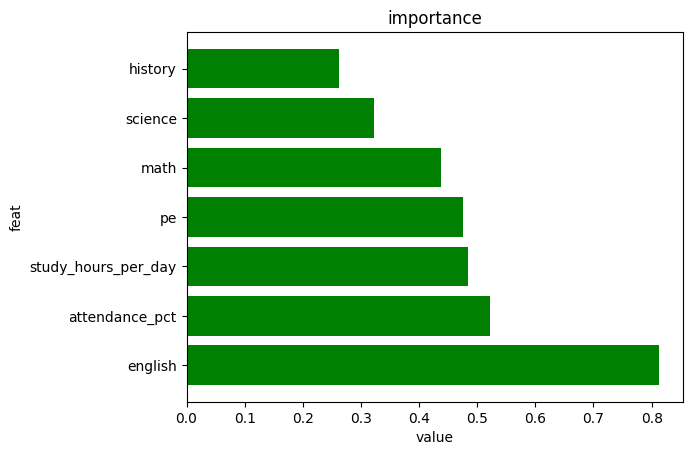

Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


C:\Users\Pranav Bhoir\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
##========PART-4 = MACHINE LEARNING WITH SCIKIT-LEARN===========

## PREAPARE DATA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature = [ 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day' ]

X = df[feature]
y = df['passed']

# split the data into train and test parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale the input values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TRAINING MODULE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("training accuracy:", train_acc)

## EVALUATE MODEL

## PREDICT ON TEST SET
y_pred = model.predict(X_test_scaled)

## TEST ACCURACY
test_acc = model.score(X_test_scaled, y_test)
print("test accuracy:", test_acc)

print("checking individual results...\n")

## predition for corect or wrong 
names = df.loc[X_test.index, 'name']

for i in range(len(y_test)):
    actual = y_test.iloc[i]
    prediction = y_pred[i]
    name = names.iloc[i]

    status = "✅ correct" if actual == prediction else "❌ wrong"

    print(name, "- actual:", actual, ", predicted:", prediction, "(", status, ")")

## FEATURE IMPORTANCE

## model coeffient 
coef = model.coef_[0]

## sorted by absulute by (largest first)
feat_imp = list(zip(feature, coef))

feat_imp.sort(key=lambda x: abs(x[1]), reverse=True)

print("feature importance:")

for name, val in feat_imp:
    print(name, ":", round(val, 3))

names = []
vals = []

for f, c in feat_imp:
    names.append(f)
    vals.append(c)

## color split
colors = []
for v in vals:
    if v > 0:
        colors.append('green')
    else:
        colors.append('red')

plt.figure()

plt.barh(names, vals, color=colors)

plt.title("importance")
plt.xlabel("value")
plt.ylabel("feat")

plt.savefig("plot8_feature_importance.png")
plt.show()

## PREDICT FOR NEW STUDENT 


new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
scaled_input = scaler.transform(new_student)

result = model.predict(scaled_input)
prediction_value = result[0]  

probabilities = model.predict_proba(scaled_input)
prob_values = probabilities[0]

if prediction_value == 1:
    print("Prediction: Pass") 
else: 
    print("Prediction: Fail")

print("Probability (Fail, Pass):", prob_values)

